<a href="https://colab.research.google.com/github/padmajakunuku/infosys_springboard_internship/blob/main/milestone_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================
# LABEL ENCODING (TARGET) + ONE-HOT ENCODING (FEATURES)
# ====================================================

# --- STEP 1: Import Libraries ---
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

# --- STEP 2: Load Dataset ---
file_path = "education_jobs_dataset_500_imputed.csv"  # or your full path
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at {file_path}. Please check path or upload again.")

df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns and Data Types:")
print(df.dtypes)

# --- STEP 3: Preview Data ---
print("\nFirst 5 rows of the dataset:")
display(df.head())

# --- STEP 4: Label Encode the Target Column ---
target_col = "Job Role"  # Target variable
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

print(f"\n✅ Label Encoding applied to target column: '{target_col}'")
print("Unique classes and their encoded values:")
for cls, val in zip(le.classes_, le.transform(le.classes_)):
    print(f"{cls} → {val}")

# --- STEP 5: Identify Categorical Columns for One-Hot Encoding ---
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Remove the target column if it's still in the list (safety check)
if target_col in cat_cols:
    cat_cols.remove(target_col)

print("\nCategorical Columns Detected (for One-Hot Encoding):", cat_cols)

# Optional: Check unique values per categorical column
for col in cat_cols:
    print(f"\nColumn: {col} (Unique values: {df[col].nunique()})")
    print(df[col].value_counts(dropna=False).head(10))

# --- STEP 6: Apply One-Hot Encoding ---
# Using sparse=True for memory efficiency and drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, sparse=True)

print("\n✅ One-Hot Encoding completed!")
print("New shape after encoding:", df_encoded.shape)

# --- STEP 7: Inspect Encoded Columns ---
print("\nSample of new columns (first 40):")
print(df_encoded.columns[:40].tolist())

# --- STEP 8: Save Encoded Dataset ---
output_path = "education_jobs_dataset_500_imputed_label_ohe.csv"
df_encoded.to_csv(output_path, index=False)

print(f"\n💾 Encoded dataset saved successfully to: {output_path}")

# --- STEP 9 (Optional): Verify Saved File ---
df_check = pd.read_csv(output_path)
print("Reloaded file shape:", df_check.shape)
print("✅ Label + One-Hot Encoded file verified and ready for model training!")

# --- STEP 10 (Optional): Save Label Encoder Mapping ---
# If you plan to decode predictions later, save the mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabel Encoder Mapping (Job Role → Encoded Value):")
print(mapping)


✅ Dataset loaded successfully!
Shape: (500, 8)

Columns and Data Types:
Name             object
Education        object
Skill            object
Certification    object
Job Role         object
Education_std    object
Degree           object
Branch           object
dtype: object

First 5 rows of the dataset:


,Name,Education,Skill,Certification,Job Role,Education_std,Degree,Branch
0,Person_1,BCA,HTML,Google IT Support,Software Developer,Bca,Bca,NaN
1,Person_2,BSc Mathematics,Data Analysis,NaN,Mathematician,BSc Mathematics,BSc,Mathematics
2,Person_3,BTech ECE,NaN,Embedded Systems Certification,Electronics Engineer,BTech Ece,BTech,Ece
3,Person_4,BTech Civil,AutoCAD,Autodesk Certified Professional,Structural Engineer,BTech Civil,BTech,Civil
4,Person_5,BTech EE,Power Systems,Power Systems Certification,Electrical Engineer,BTech Ee,BTech,Ee



✅ Label Encoding applied to target column: 'Job Role'
Unique classes and their encoded values:
Backend Developer → 0
Business Analyst → 1
Chemist → 2
Civil Engineer → 3
Control Engineer → 4
Data Analyst → 5
Data Scientist → 6
Design Engineer → 7
Electrical Engineer → 8
Electronics Engineer → 9
Embedded Engineer → 10
Lab Analyst → 11
Lab Assistant → 12
Manufacturing Engineer → 13
Mathematician → 14
Mechanical Engineer → 15
Power Engineer → 16
Research Scientist → 17
Site Engineer → 18
Software Developer → 19
Software Engineer → 20
Statistician → 21
Structural Engineer → 22
System Analyst → 23
VLSI Engineer → 24
Web Developer → 25
nan → 26

Categorical Columns Detected (for One-Hot Encoding): ['Name', 'Education', 'Skill', 'Certification', 'Education_std', 'Degree', 'Branch']

Column: Name (Unique values: 500)
Name
Person_500    1
Person_1      1
Person_2      1
Person_3      1
Person_484    1
Person_483    1
Person_482    1
Person_481    1
Person_480    1
Person_479    1
Name: count, d

In [ ]:
# ====================================================
# PART 4: TRAIN–TEST SPLIT (Target unaffected)
# ====================================================

# --- STEP 1: Import Libraries ---
import pandas as pd
from sklearn.model_selection import train_test_split

# --- STEP 2: Load the preprocessed dataset ---
# Use the encoded + scaled dataset you already created
file_path = "education_jobs_dataset_500_imputed_label_ohe.csv"
df_final = pd.read_csv(file_path)

print("✅ Dataset loaded for train–test split!")
print("Shape:", df_final.shape)

# --- STEP 3: Define target column ---
target_col = "Job Role"

# --- STEP 4: Separate features (X) and target (y) ---
X = df_final.drop(columns=[target_col])
y = df_final[target_col]

print(f"Features shape: {X.shape}, Target shape: {y.shape}")

# --- STEP 5: Split into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% test data
    random_state=42,      # reproducibility
    stratify=y            # maintain class balance
)

# --- STEP 6: Display Summary ---
print("\n✅ Data split completed successfully!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nUnique class distribution in Train:")
print(y_train.value_counts(normalize=True))

print("\nUnique class distribution in Test:")
print(y_test.value_counts(normalize=True))



✅ Dataset loaded for train–test split!
Shape: (500, 577)
Features shape: (500, 576), Target shape: (500,)

✅ Data split completed successfully!
Train shape: (400, 576)
Test shape: (100, 576)

Unique class distribution in Train:
Job Role
5     0.1050
21    0.0625
8     0.0550
17    0.0525
9     0.0500
12    0.0425
11    0.0425
14    0.0425
22    0.0400
4     0.0400
20    0.0400
15    0.0375
23    0.0350
24    0.0325
10    0.0325
13    0.0300
6     0.0300
16    0.0275
3     0.0250
0     0.0250
1     0.0250
7     0.0250
2     0.0250
19    0.0250
18    0.0225
26    0.0150
25    0.0150
Name: proportion, dtype: float64

Unique class distribution in Test:
Job Role
5     0.11
21    0.06
8     0.05
11    0.05
17    0.05
9     0.05
4     0.04
22    0.04
12    0.04
14    0.04
20    0.04
15    0.04
6     0.03
2     0.03
16    0.03
3     0.03
10    0.03
23    0.03
19    0.03
1     0.03
13    0.03
24    0.03
18    0.02
25    0.02
0     0.02
7     0.02
26    0.01
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



✅ Logistic Regression Metrics:
Accuracy  : 0.4200
Precision : 0.3269
Recall    : 0.4200
F1 Score  : 0.3436


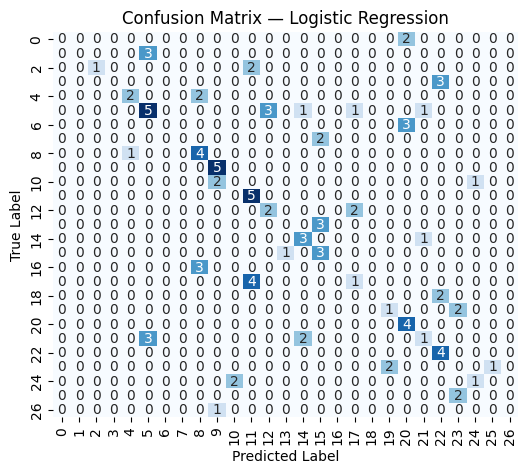

In [ ]:
## ====================================================
# PART 5: LOGISTIC REGRESSION (Improved)
# ====================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
import numpy as np

# --- Train Model ---
scaler = StandardScaler(with_mean=False)
log_reg = make_pipeline(
    scaler,
    LogisticRegression(max_iter=2000, solver='liblinear', multi_class='ovr', random_state=42)
)
log_reg.fit(X_train, y_train)

# --- Predictions ---
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)

# --- Metrics ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\n✅ Logistic Regression Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

# --- Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



🚀 Training Random Forest model...

✅ Random Forest Evaluation Results:
Accuracy: 0.4300
F1 Score: 0.3846

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.67      0.50      0.57         4
           5       0.38      0.45      0.42        11
           6       0.20      0.33      0.25         3
           7       0.00      0.00      0.00         2
           8       0.50      0.60      0.55         5
           9       0.56      1.00      0.71         5
          10       0.00      0.00      0.00         3
          11       0.56      1.00      0.71         5
          12       0.25      0.25      0.25         4
          13       0.50      0.33      0.40         3
          14       0.50      0.75      0.60         4
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


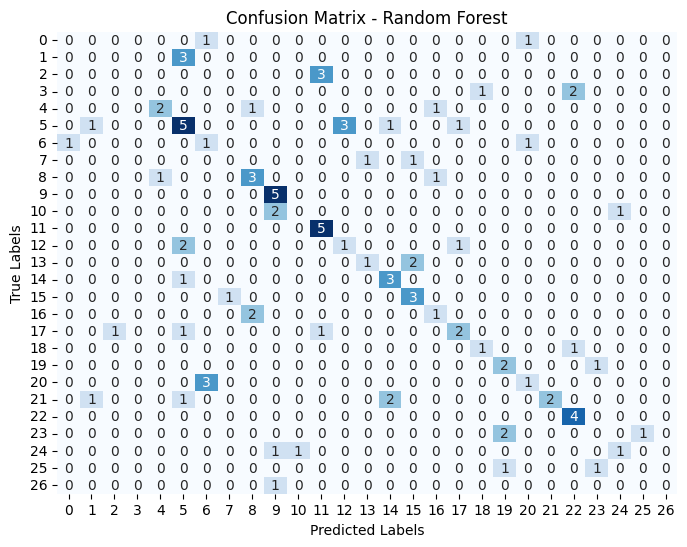

/tmp/ipython-input-3190510284.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


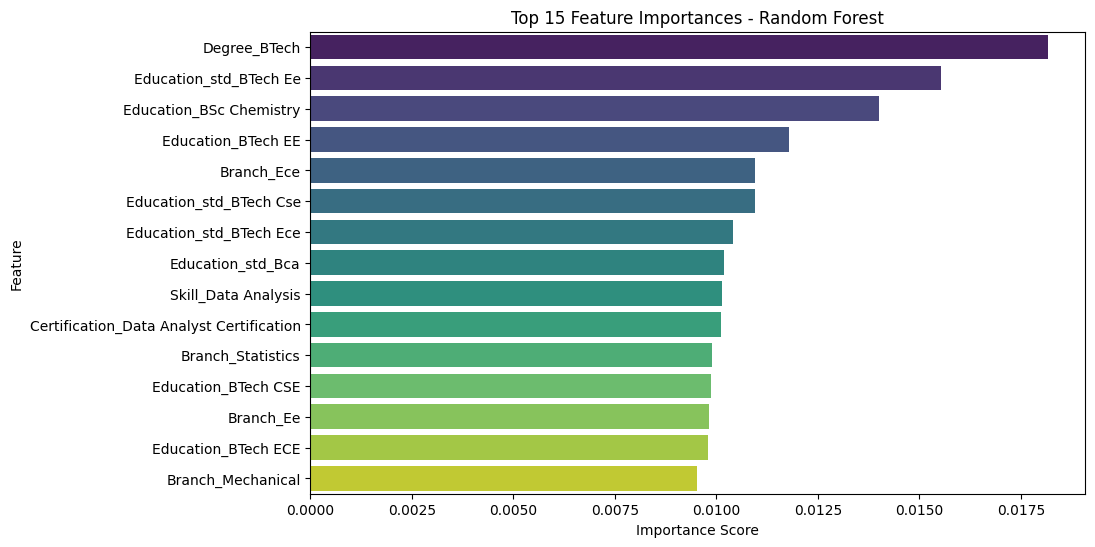

In [ ]:
# ====================================================
# PART 6: RANDOM FOREST CLASSIFIER
# ====================================================

# --- STEP 1: Import Libraries ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 2: Initialize and Train Model ---
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # let model decide optimal depth
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

print("🚀 Training Random Forest model...")
rf_model.fit(X_train, y_train)

# --- STEP 3: Make Predictions ---
y_pred = rf_model.predict(X_test)

# --- STEP 4: Evaluate Model ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ Random Forest Evaluation Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# --- STEP 5: Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- STEP 6: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# --- STEP 7: Feature Importance Visualization ---
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


⚡ Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:09:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ XGBoost Evaluation Results:
Accuracy: 0.4000
F1 Score: 0.3791

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.20      0.33      0.25         3
           3       0.00      0.00      0.00         3
           4       0.50      0.50      0.50         4
           5       0.31      0.36      0.33        11
           6       0.20      0.33      0.25         3
           7       0.00      0.00      0.00         2
           8       0.40      0.40      0.40         5
           9       0.83      1.00      0.91         5
          10       0.50      0.33      0.40         3
          11       0.40      0.40      0.40         5
          12       0.33      0.25      0.29         4
          13       0.67      0.67      0.67         3
          14       0.25      0.25      0.25         4
          15       0.50      0.50      0.50 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


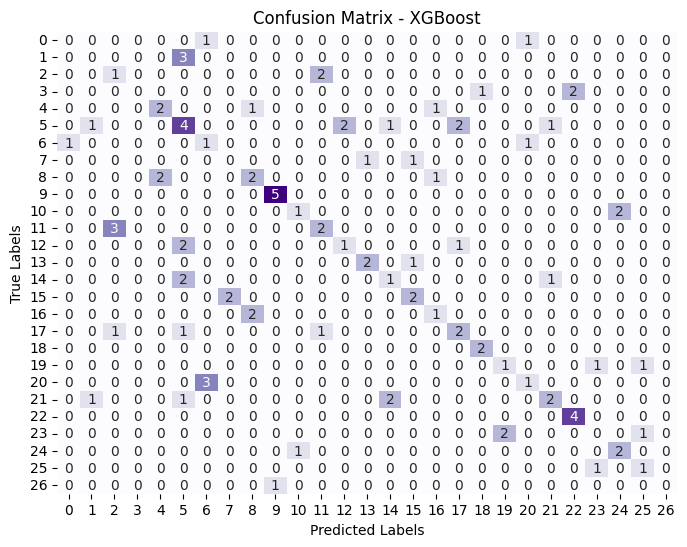

/tmp/ipython-input-1710173535.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="mako")


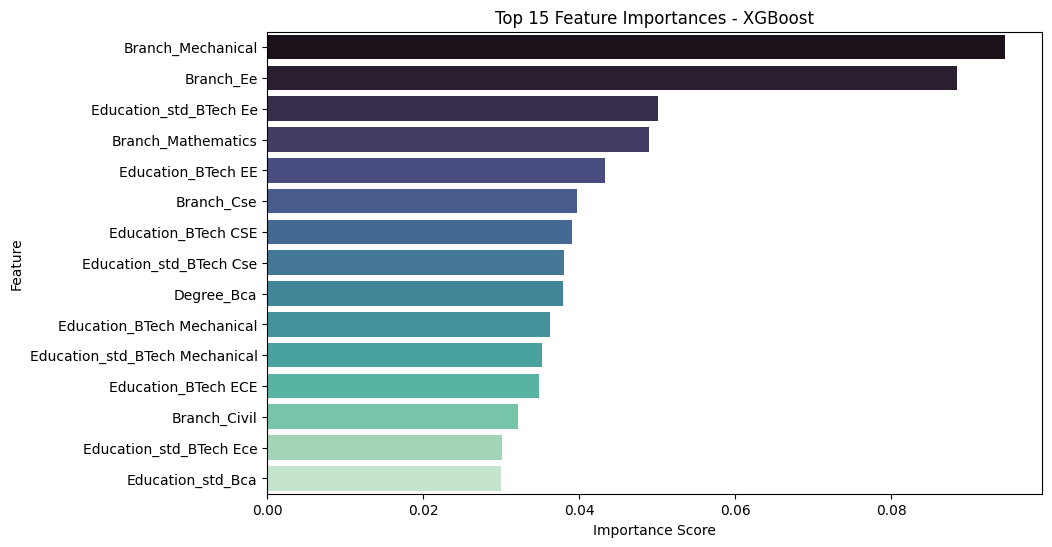

In [ ]:
# ====================================================
# PART 7: XGBOOST CLASSIFIER (No ROC)
# ====================================================

# --- STEP 1: Import Libraries ---
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- STEP 2: Initialize and Train Model ---
xgb_model = XGBClassifier(
    n_estimators=300,          # number of trees
    learning_rate=0.05,        # smaller LR for better generalization
    max_depth=6,               # depth of each tree
    subsample=0.8,             # use 80% of data for each tree
    colsample_bytree=0.8,      # use 80% of features per tree
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print("⚡ Training XGBoost model...")
xgb_model.fit(X_train, y_train)

# --- STEP 3: Make Predictions ---
y_pred = xgb_model.predict(X_test)

# --- STEP 4: Evaluate Model ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ XGBoost Evaluation Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# --- STEP 5: Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- STEP 6: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# --- STEP 7: Feature Importance Visualization ---
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="mako")
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()



⚙️ Training AdaBoost model...

✅ AdaBoost Evaluation Results:
Accuracy: 0.4200
F1 Score: 0.2716

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.67      0.50      0.57         4
           5       0.38      1.00      0.55        11
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         2
           8       0.44      0.80      0.57         5
           9       0.42      1.00      0.59         5
          10       0.00      0.00      0.00         3
          11       0.42      1.00      0.59         5
          12       0.00      0.00      0.00         4
          13       0.00      0.00      0.00         3
          14       0.00      0.00      0.00         4
          15 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


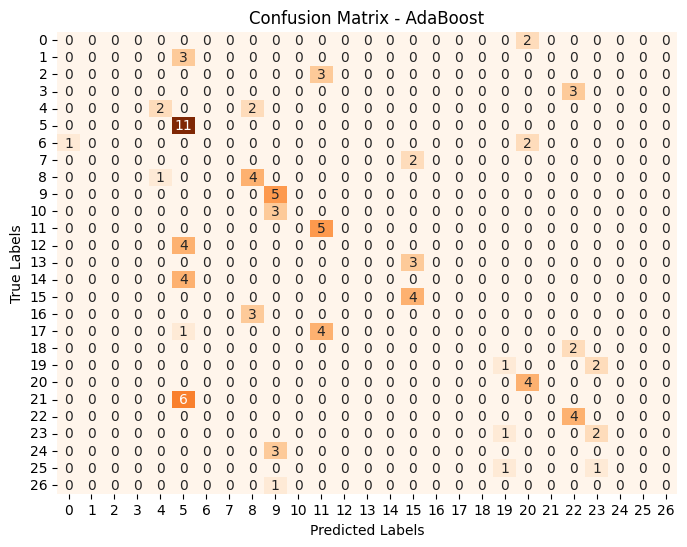

/tmp/ipython-input-4248096204.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="autumn")


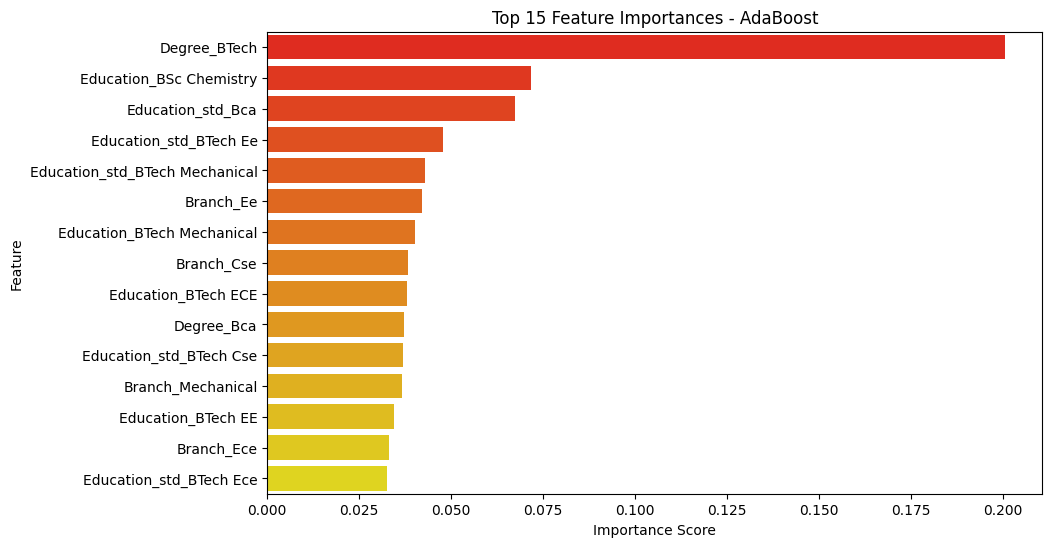

In [ ]:
# ====================================================
# PART 8: ADABOOST CLASSIFIER (No ROC)
# ====================================================

# --- STEP 1: Import Libraries ---
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- STEP 2: Initialize and Train Model ---
# Using DecisionTreeClassifier as the base estimator (default is stumps)
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

print("⚙️ Training AdaBoost model...")
ada_model.fit(X_train, y_train)

# --- STEP 3: Make Predictions ---
y_pred = ada_model.predict(X_test)

# --- STEP 4: Evaluate Model ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ AdaBoost Evaluation Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# --- STEP 5: Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- STEP 6: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# --- STEP 7: Feature Importance Visualization ---
feature_importances = pd.Series(ada_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="autumn")
plt.title("Top 15 Feature Importances - AdaBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


💻 Training SVM model...

✅ SVM Evaluation Results:
Accuracy: 0.4100
F1 Score: 0.2711

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.45      0.45      0.45        11
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         2
           8       0.42      1.00      0.59         5
           9       0.42      1.00      0.59         5
          10       0.00      0.00      0.00         3
          11       0.42      1.00      0.59         5
          12       0.33      0.50      0.40         4
          13       0.00      0.00      0.00         3
          14       0.50      1.00      0.67         4
          15       0.44 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


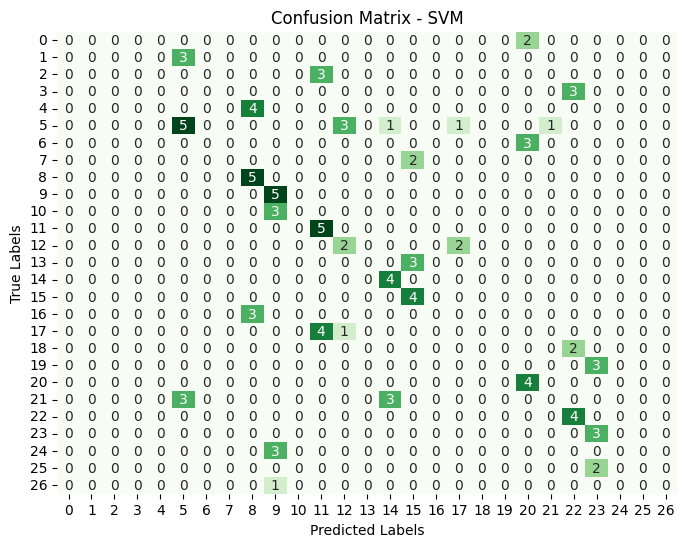

In [ ]:
# ====================================================
# PART 9: SUPPORT VECTOR MACHINE (SVM) CLASSIFIER (No ROC)
# ====================================================

# --- STEP 1: Import Libraries ---
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 2: Initialize and Train Model ---
# Use probability=True if you plan to do ROC later
svm_model = SVC(
    kernel='rbf',          # Radial Basis Function kernel (default)
    C=1.0,                 # Regularization strength
    gamma='scale',         # Kernel coefficient
    probability=False,     # Change to True if ROC is needed later
    random_state=42
)

print("💻 Training SVM model...")
svm_model.fit(X_train, y_train)

# --- STEP 3: Make Predictions ---
y_pred = svm_model.predict(X_test)

# --- STEP 4: Evaluate Model ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ SVM Evaluation Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# --- STEP 5: Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- STEP 6: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


🌳 Training Decision Tree model...

✅ Decision Tree Evaluation Results:
Accuracy: 0.4200
F1 Score: 0.3263

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.67      0.50      0.57         4
           5       0.36      0.45      0.40        11
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         2
           8       0.44      0.80      0.57         5
           9       0.62      1.00      0.77         5
          10       0.00      0.00      0.00         3
          11       0.71      1.00      0.83         5
          12       0.25      0.25      0.25         4
          13       0.00      0.00      0.00         3
          14       0.50      1.00      0.67         4
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


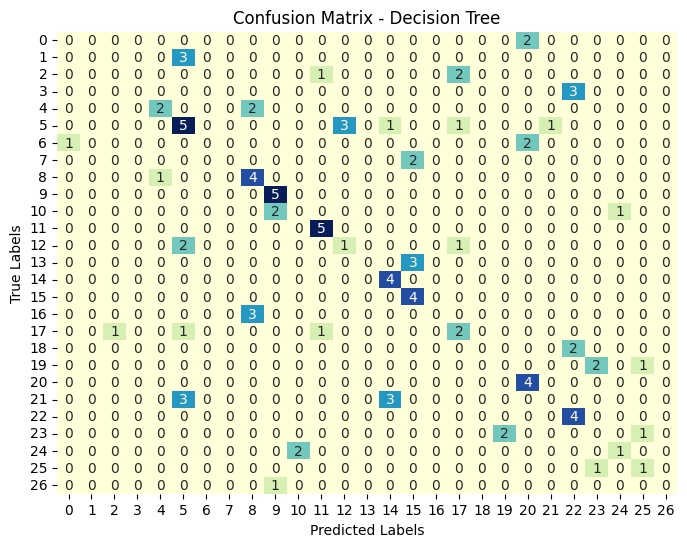

In [ ]:
# ====================================================
# PART 10: DECISION TREE CLASSIFIER (No ROC)
# ====================================================

# --- STEP 1: Import Libraries ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- STEP 2: Initialize and Train Model ---
dt_model = DecisionTreeClassifier(
    criterion='gini',     # can also try 'entropy' or 'log_loss'
    max_depth=None,       # None → grow until all leaves are pure
    min_samples_split=2,
    random_state=42
)

print("🌳 Training Decision Tree model...")
dt_model.fit(X_train, y_train)

# --- STEP 3: Make Predictions ---
y_pred = dt_model.predict(X_test)

# --- STEP 4: Evaluate Model ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ Decision Tree Evaluation Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# --- STEP 5: Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- STEP 6: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
# --- (Optional) Visualize the Tree Structure ---
# Warning: only use for small trees (it can be very large)
# plt.figure(figsize=(20, 10))
# plot_tree(dt_model, filled=True, feature_names=X_train.columns, class_names=True, max_depth=3)
# plt.title("Decision Tree Structure (Depth ≤ 3)")
# plt.show()



💻 Training KNN model...

✅ KNN Evaluation Results:
Accuracy: 0.3300
F1 Score: 0.2811

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.67      0.57         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.50      0.50      0.50         4
           5       0.18      0.18      0.18        11
           6       0.25      0.33      0.29         3
           7       0.20      0.50      0.29         2
           8       0.40      0.40      0.40         5
           9       0.45      1.00      0.62         5
          10       0.00      0.00      0.00         3
          11       0.56      1.00      0.71         5
          12       0.33      0.25      0.29         4
          13       0.50      0.67      0.57         3
          14       0.33      0.25      0.29         4
          15       0.00 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


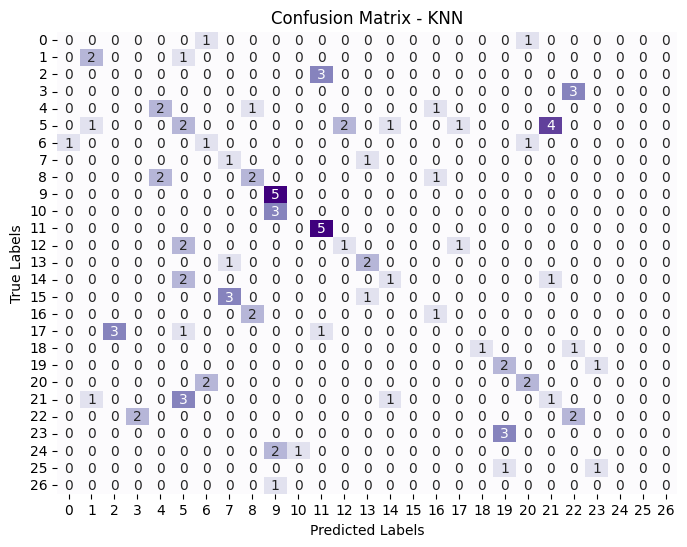

In [ ]:
# ====================================================
# PART 10: K-NEAREST NEIGHBORS (KNN) CLASSIFIER
# ====================================================

# --- STEP 1: Import Libraries ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 2: Initialize and Train KNN Model ---
knn_model = KNeighborsClassifier(
    n_neighbors=5,    # Default = 5
    weights='uniform', # Can also try 'distance'
    metric='minkowski' # Euclidean distance (p=2)
)

print("💻 Training KNN model...")
knn_model.fit(X_train, y_train)

# --- STEP 3: Make Predictions ---
y_pred = knn_model.predict(X_test)

# --- STEP 4: Evaluate Model ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ KNN Evaluation Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# --- STEP 5: Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- STEP 6: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



🔹 Cross-validating: Logistic Regression

🔹 Cross-validating: Decision Tree

🔹 Cross-validating: Random Forest

🔹 Cross-validating: XGBoost

🔹 Cross-validating: AdaBoost

🔹 Cross-validating: SVM

🔹 Cross-validating: KNN

🔹 Evaluating: KMeans (unsupervised)

✅ Cross-Validation Results Summary:
                   Model  Mean Accuracy  Std Accuracy  Mean F1 Score  \
7  KMeans (Unsupervised)          0.456      0.000000       0.351095   
2          Random Forest          0.388      0.047074       0.345948   
6                    KNN          0.360      0.038471       0.326736   
3                XGBoost          0.352      0.025612       0.323588   
1          Decision Tree          0.370      0.024495       0.309115   
0    Logistic Regression          0.356      0.024166       0.294853   
5                    SVM          0.402      0.029257       0.282357   
4               AdaBoost          0.232      0.037094       0.111734   

   Std F1 Score  
7      0.000000  
2      0.048162  
6  

/tmp/ipython-input-3759326079.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Mean F1 Score", y="Model", palette="viridis")


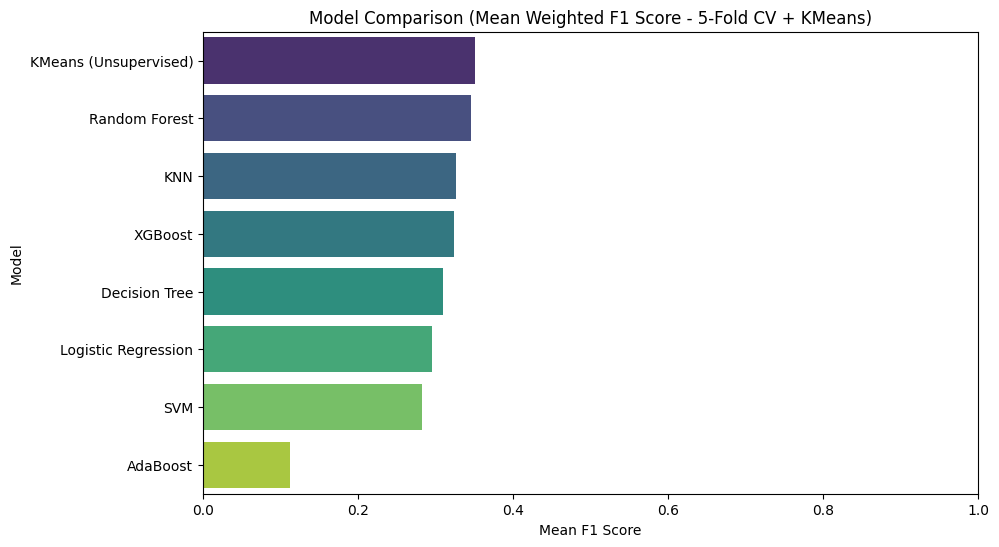

/tmp/ipython-input-3759326079.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Mean Accuracy", y="Model", palette="coolwarm")


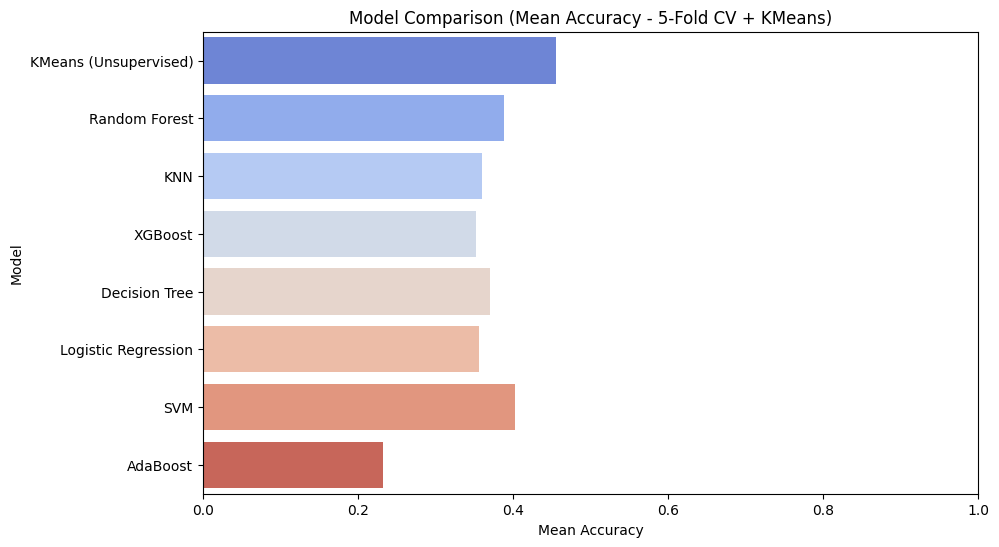

In [ ]:
# ====================================================
# PART 11: CROSS-VALIDATION COMPARISON (All Models + KNN + KMeans)
# ====================================================

# --- STEP 1: Import Libraries ---
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score
from scipy.stats import mode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 2: Define Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# --- STEP 3: Cross-Validation Setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average="weighted")

# --- STEP 4: Perform Cross-Validation ---
results = []
for name, model in models.items():
    print(f"\n🔹 Cross-validating: {name}")
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring=f1_macro, n_jobs=-1)

    results.append({
        "Model": name,
        "Mean Accuracy": np.mean(acc_scores),
        "Std Accuracy": np.std(acc_scores),
        "Mean F1 Score": np.mean(f1_scores),
        "Std F1 Score": np.std(f1_scores)
    })

# --- STEP 5: Handle KMeans (Unsupervised) Separately ---
print("\n🔹 Evaluating: KMeans (unsupervised)")

# KMeans setup
num_classes = len(np.unique(y))
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
kmeans.fit(X)

# Map clusters to most common true label
labels = np.zeros_like(kmeans.labels_)
for i in range(num_classes):
    mask = (kmeans.labels_ == i)
    if np.any(mask):
        labels[mask] = mode(y[mask], keepdims=False).mode

# Calculate accuracy and F1 for mapped clusters
kmeans_acc = accuracy_score(y, labels)
kmeans_f1 = f1_score(y, labels, average="weighted")

results.append({
    "Model": "KMeans (Unsupervised)",
    "Mean Accuracy": kmeans_acc,
    "Std Accuracy": 0,
    "Mean F1 Score": kmeans_f1,
    "Std F1 Score": 0
})

# --- STEP 6: Create Results DataFrame ---
results_df = pd.DataFrame(results).sort_values(by="Mean F1 Score", ascending=False)
print("\n✅ Cross-Validation Results Summary:")
print(results_df)

# --- STEP 7: Visualization ---
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Mean F1 Score", y="Model", palette="viridis")
plt.title("Model Comparison (Mean Weighted F1 Score - 5-Fold CV + KMeans)")
plt.xlabel("Mean F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Mean Accuracy", y="Model", palette="coolwarm")
plt.title("Model Comparison (Mean Accuracy - 5-Fold CV + KMeans)")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()
